# Forest Cover Type Classification

This project builds a machine learning model to **predict forest cover type** using environmental and geographic data.

The dataset contains **581,012 observations and 55 columns**, including terrain features such as:

- Elevation
- Slope
- Distance to hydrology and roadways
- Hillshade measurements

It also includes **one-hot encoded wilderness areas and soil types**.

The target variable is **`class`**, which represents the forest cover type.

The goal is to train a model that can **classify the correct forest cover type from these features**.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Deep learning
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
print(tf.__version__)

2.20.0


## Load and Inspect Dataset

In this section we:

- Load the forest cover dataset from the project data directory
- Perform a quick inspection of the dataset
- Check the dataset shape, column names, and data types
- Ensure there are no missing values
- Examine the distribution of the target variable (`class`)

This step helps us understand the structure of the dataset before applying preprocessing and model training.

In [5]:
# ==============================
# Load Dataset
# ==============================

# Notebook is in /notebooks
# CSV is in /data
# So we move up one directory with ".."

df = pd.read_csv("../data/cover_data_raw.csv")


# ==============================
# Quick Data Inspection
# ==============================

# View first rows
print(df.head())

# View column names
print("\nColumn names:")
print(df.columns)

# Shape of dataset
print("\nDataset shape:", df.shape)

# Column types and null checks
print("\nDataset info:")
print(df.info())


# ==============================
# Data Quality Checks
# ==============================

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


# ==============================
# Target Variable Distribution
# ==============================

# Class counts
print("\nClass counts:")
print(df["class"].value_counts())

# Class percentages
print("\nClass percentages:")
print(df["class"].value_counts(normalize=True) * 100)

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

## Feature and Target Separation

Now that we have explored the dataset, we separate the **input features** from the **target variable**.

- `X` contains all columns **except** the target (`class`).
- `y` contains the **target variable** (`class`), which we want to predict.

Next, we will split the dataset into **training and test sets** for model evaluation.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================
# Feature / Target Separation
# ==============================

# Drop redundant one-hot columns
X = df.drop(columns=["class", "Wilderness_Area4", "Soil_Type40"])
y = df["class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# ==============================
# Train / Test Split
# ==============================

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# ==============================
# Scaling Numeric Features
# ==============================

# Identify numeric columns
numeric_cols = [
    "Elevation", "Aspect", "Slope", 
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nScaled numeric features for neural network training.")

# ==============================
# Optional: Low-Variance / Mostly-Zero Columns
# ==============================

# Calculate percentage of zeros for each column
zero_pct = (X == 0).sum() / len(X) * 100
print("\nPercentage of zeros per column (sorted):")
print(zero_pct.sort_values())

Features shape: (581012, 52)
Target shape: (581012,)
Training set shape: (464809, 52)
Test set shape: (116203, 52)

Scaled numeric features for neural network training.

Percentage of zeros per column (sorted):
Elevation                              0.000000
Hillshade_Noon                         0.000861
Hillshade_9am                          0.002237
Horizontal_Distance_To_Fire_Points     0.008778
Horizontal_Distance_To_Roadways        0.021342
Slope                                  0.112906
Hillshade_3pm                          0.230288
Aspect                                 0.845766
Horizontal_Distance_To_Hydrology       4.234508
Vertical_Distance_To_Hydrology         6.654768
Wilderness_Area1                      55.113492
Wilderness_Area3                      56.392639
Soil_Type29                           80.164437
Soil_Type23                           90.060102
Soil_Type32                           90.960772
Soil_Type33                           92.228388
Soil_Type22          

## Build and Train the Neural Network

We will now build a **fully connected neural network** using TensorFlow and Keras.  

Steps:

1. Split the **existing training data** into a smaller training set and a **validation set** (80/20).  
2. Convert the target variable into **one-hot encoding** for multi-class classification.  
3. Build a **simple dense neural network**.  
4. Compile with **categorical crossentropy loss** and the **Adam optimizer**.  
5. Train with an **early stopping callback** to prevent overfitting.

In [9]:
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# ==============================
# Train / Validation Split
# ==============================

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Training set shape:", X_train_final.shape)
print("Validation set shape:", X_val.shape)

# ==============================
# Convert target to categorical (one-hot)
# ==============================

num_classes = len(y.unique())  # 7 classes
y_train_cat = to_categorical(y_train_final - 1, num_classes=num_classes)  # subtract 1 for 0-indexing
y_val_cat = to_categorical(y_val - 1, num_classes=num_classes)
y_test_cat = to_categorical(y_test - 1, num_classes=num_classes)

# ==============================
# Build the Model
# ==============================

input_dim = X_train_final.shape[1]

model = keras.Sequential([
    layers.InputLayer(input_shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# ==============================
# Compile the Model
# ==============================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Train the Model
# ==============================

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=256,
    callbacks=[early_stop]
)

Training set shape: (371847, 52)
Validation set shape: (92962, 52)


C:\AI_Resources\Anaconda\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7466 - loss: 0.6025 - val_accuracy: 0.7813 - val_loss: 0.5098
Epoch 2/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7945 - loss: 0.4818 - val_accuracy: 0.8055 - val_loss: 0.4605
Epoch 3/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8160 - loss: 0.4367 - val_accuracy: 0.8239 - val_loss: 0.4242
Epoch 4/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8295 - loss: 0.4079 - val_accuracy: 0.8347 - val_loss: 0.3998
Epoch 5/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8399 - loss: 0.3860 - val_accuracy: 0.8434 - val_loss: 0.3797
Epoch 6/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8465 - loss: 0.3708 - val_accuracy: 0.8465 - val_loss: 0.3676
Epoch 7/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8520 - loss: 0.3582 - val_accuracy: 0.8517 - val_loss: 0.3593
Epoch 8/20
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8579 - loss: 0.3469 - 

## Hyperparameter Tuning

We'll adjust hyperparameters to improve performance:

- Number of hidden layers and units
- Activation functions
- Dropout rate
- Optimizer type and learning rate
- Batch size
- Early stopping patience

We'll train the model on the existing training set and validate on the existing validation set.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ==============================
# Build Model with new hyperparameters
# ==============================
num_classes = y_train_cat.shape[1]
input_dim = X_train_final.shape[1]

model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),  # increased units
    Dropout(0.4),                                             # added dropout
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# ==============================
# Compile Model
# ==============================
optimizer = Adam(learning_rate=0.0005)  # changed learning rate
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Early Stopping
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,  # increased patience
    restore_best_weights=True
)

# ==============================
# Train Model
# ==============================
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,         # increased epochs
    batch_size=512,    # changed batch size
    callbacks=[early_stop],
    verbose=2
)

C:\AI_Resources\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
727/727 - 9s - 12ms/step - accuracy: 0.6980 - loss: 0.7306 - val_accuracy: 0.7487 - val_loss: 0.5791
Epoch 2/30
727/727 - 5s - 7ms/step - accuracy: 0.7435 - loss: 0.5951 - val_accuracy: 0.7683 - val_loss: 0.5312
Epoch 3/30
727/727 - 5s - 7ms/step - accuracy: 0.7587 - loss: 0.5579 - val_accuracy: 0.7842 - val_loss: 0.5000
Epoch 4/30
727/727 - 5s - 7ms/step - accuracy: 0.7700 - loss: 0.5328 - val_accuracy: 0.7959 - val_loss: 0.4767
Epoch 5/30
727/727 - 5s - 7ms/step - accuracy: 0.7778 - loss: 0.5145 - val_accuracy: 0.8043 - val_loss: 0.4570
Epoch 6/30
727/727 - 5s - 7ms/step - accuracy: 0.7856 - loss: 0.4991 - val_accuracy: 0.8132 - val_loss: 0.4422
Epoch 7/30
727/727 - 5s - 7ms/step - accuracy: 0.7905 - loss: 0.4874 - val_accuracy: 0.8172 - val_loss: 0.4308
Epoch 8/30
727/727 - 5s - 7ms/step - accuracy: 0.7947 - loss: 0.4780 - val_accuracy: 0.8212 - val_loss: 0.4238
Epoch 9/30
727/727 - 5s - 7ms/step - accuracy: 0.7988 - loss: 0.4694 - val_accuracy: 0.8274 - val_loss: 0.4128


## Further Hyperparameter Tuning

We'll try some additional adjustments to improve validation performance:

- Reduce batch size to 256 for potentially better convergence
- Adjust learning rate slightly lower to 0.0003
- Increase hidden layer units modestly (256 → 512)
- Experiment with `gelu` activation for hidden layers
- Slightly increase dropout to prevent overfitting
- Increase early stopping patience to allow more epochs if needed

We'll continue using the same train/validation split and evaluate improvements before testing on the holdout set.

In [11]:
from tensorflow.keras.activations import gelu

# ==============================
# Build Model with new hyperparameters
# ==============================
model = Sequential([
    Dense(512, activation=gelu, input_shape=(input_dim,)),  # wider + GELU
    Dropout(0.45),                                         # slightly more dropout
    Dense(256, activation=gelu),
    Dropout(0.35),
    Dense(128, activation=gelu),
    Dense(num_classes, activation='softmax')
])

# ==============================
# Compile Model
# ==============================
optimizer = Adam(learning_rate=0.0003)  # slightly lower LR
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Early Stopping
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,  # slightly more patience
    restore_best_weights=True
)

# ==============================
# Train Model
# ==============================
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=40,        # allow more epochs
    batch_size=256,   # smaller batch size
    callbacks=[early_stop],
    verbose=2
)

C:\AI_Resources\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
1453/1453 - 17s - 12ms/step - accuracy: 0.7160 - loss: 0.6759 - val_accuracy: 0.7422 - val_loss: 0.5865
Epoch 2/40
1453/1453 - 14s - 10ms/step - accuracy: 0.7434 - loss: 0.5874 - val_accuracy: 0.7632 - val_loss: 0.5403
Epoch 3/40
1453/1453 - 14s - 10ms/step - accuracy: 0.7593 - loss: 0.5511 - val_accuracy: 0.7815 - val_loss: 0.5062
Epoch 4/40
1453/1453 - 14s - 10ms/step - accuracy: 0.7735 - loss: 0.5244 - val_accuracy: 0.7956 - val_loss: 0.4738
Epoch 5/40
1453/1453 - 14s - 10ms/step - accuracy: 0.7832 - loss: 0.5018 - val_accuracy: 0.8075 - val_loss: 0.4518
Epoch 6/40
1453/1453 - 15s - 10ms/step - accuracy: 0.7919 - loss: 0.4828 - val_accuracy: 0.8147 - val_loss: 0.4303
Epoch 7/40
1453/1453 - 15s - 10ms/step - accuracy: 0.7989 - loss: 0.4673 - val_accuracy: 0.8248 - val_loss: 0.4141
Epoch 8/40
1453/1453 - 14s - 10ms/step - accuracy: 0.8050 - loss: 0.4544 - val_accuracy: 0.8315 - val_loss: 0.4008
Epoch 9/40
1453/1453 - 14s - 10ms/step - accuracy: 0.8107 - loss: 0.4428 - val_a

## Fine-Tuning Based on Best-Performing Model

We'll use the original two-hidden-layer model (128 → 64 units with ReLU), which produced the best validation accuracy (~87.9%).

Next, we'll try:
- Slightly reducing the batch size to 128 for more gradient updates per epoch
- Adjusting the learning rate slightly
- Keeping early stopping with patience of 5 to allow a few more epochs if needed

We'll keep the model simple to avoid overfitting, since larger/wider networks did not improve performance.

In [12]:
# ==============================
# Build the Best-Performing Base Model
# ==============================
input_dim = X_train_final.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# ==============================
# Compile Model with small LR tweak
# ==============================
optimizer = Adam(learning_rate=0.0005)  # slightly smaller than default

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Early Stopping
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,  # a little more patience
    restore_best_weights=True
)

# ==============================
# Train Model
# ==============================
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,         # allow more epochs
    batch_size=128,    # smaller batch size
    callbacks=[early_stop],
    verbose=2
)

C:\AI_Resources\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
2906/2906 - 10s - 3ms/step - accuracy: 0.7469 - loss: 0.6032 - val_accuracy: 0.7779 - val_loss: 0.5194
Epoch 2/30
2906/2906 - 7s - 3ms/step - accuracy: 0.7919 - loss: 0.4874 - val_accuracy: 0.8021 - val_loss: 0.4685
Epoch 3/30
2906/2906 - 8s - 3ms/step - accuracy: 0.8103 - loss: 0.4467 - val_accuracy: 0.8151 - val_loss: 0.4393
Epoch 4/30
2906/2906 - 7s - 3ms/step - accuracy: 0.8234 - loss: 0.4204 - val_accuracy: 0.8272 - val_loss: 0.4143
Epoch 5/30
2906/2906 - 8s - 3ms/step - accuracy: 0.8324 - loss: 0.4014 - val_accuracy: 0.8322 - val_loss: 0.4006
Epoch 6/30
2906/2906 - 7s - 3ms/step - accuracy: 0.8393 - loss: 0.3863 - val_accuracy: 0.8339 - val_loss: 0.3939
Epoch 7/30
2906/2906 - 8s - 3ms/step - accuracy: 0.8448 - loss: 0.3742 - val_accuracy: 0.8441 - val_loss: 0.3730
Epoch 8/30
2906/2906 - 7s - 3ms/step - accuracy: 0.8493 - loss: 0.3641 - val_accuracy: 0.8470 - val_loss: 0.3696
Epoch 9/30
2906/2906 - 8s - 3ms/step - accuracy: 0.8537 - loss: 0.3554 - val_accuracy: 0.8413 -

## Attempt to Improve Validation Accuracy

We'll build on the best-performing model with subtle enhancements:

- Slightly increase the second hidden layer from 64 → 80 units
- Add a Dropout layer (0.1) to reduce overfitting
- Use `ReduceLROnPlateau` to decrease learning rate if validation loss plateaus
- Keep batch size at 128 and early stopping with patience=5

This should help the model converge slightly better and improve validation accuracy.

In [13]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ==============================
# Build Enhanced Model
# ==============================
input_dim = X_train_final.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dense(80, activation='relu'),
    Dropout(0.1),  # small dropout to reduce overfitting
    Dense(num_classes, activation='softmax')
])

# ==============================
# Compile Model
# ==============================
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Callbacks
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # reduce LR by half
    patience=3,
    verbose=1
)

# ==============================
# Train Model
# ==============================
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=40,          # allow more epochs
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

C:\AI_Resources\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
2906/2906 - 11s - 4ms/step - accuracy: 0.7357 - loss: 0.6274 - val_accuracy: 0.7758 - val_loss: 0.5250 - learning_rate: 5.0000e-04
Epoch 2/40
2906/2906 - 9s - 3ms/step - accuracy: 0.7842 - loss: 0.5050 - val_accuracy: 0.8018 - val_loss: 0.4694 - learning_rate: 5.0000e-04
Epoch 3/40
2906/2906 - 9s - 3ms/step - accuracy: 0.8025 - loss: 0.4631 - val_accuracy: 0.8166 - val_loss: 0.4378 - learning_rate: 5.0000e-04
Epoch 4/40
2906/2906 - 10s - 3ms/step - accuracy: 0.8152 - loss: 0.4371 - val_accuracy: 0.8215 - val_loss: 0.4218 - learning_rate: 5.0000e-04
Epoch 5/40
2906/2906 - 9s - 3ms/step - accuracy: 0.8246 - loss: 0.4170 - val_accuracy: 0.8343 - val_loss: 0.3980 - learning_rate: 5.0000e-04
Epoch 6/40
2906/2906 - 10s - 3ms/step - accuracy: 0.8324 - loss: 0.3994 - val_accuracy: 0.8355 - val_loss: 0.3916 - learning_rate: 5.0000e-04
Epoch 7/40
2906/2906 - 9s - 3ms/step - accuracy: 0.8381 - loss: 0.3870 - val_accuracy: 0.8462 - val_loss: 0.3725 - learning_rate: 5.0000e-04
Epoch 8/40

## Test Set Evaluation

Now that we have our best-performing model, we will:

1. Evaluate the model on the test set to obtain overall accuracy and loss.
2. Generate predictions for the test set.
3. Create a **classification report** to examine precision, recall, and F1-score for each class.
4. Plot a **confusion matrix heatmap** to visually assess which classes are being predicted correctly or confused.

This will give us a clear understanding of how well the model generalises to unseen data.

3632/3632 - 7s - 2ms/step - accuracy: 0.8962 - loss: 0.2582

Test Loss: 0.2582
Test Accuracy: 0.8962
3632/3632 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

Classification Report:

              precision    recall  f1-score   support

           1       0.90      0.88      0.89     42368
           2       0.90      0.92      0.91     56661
           3       0.87      0.89      0.88      7151
           4       0.85      0.75      0.79       549
           5       0.82      0.65      0.73      1899
           6       0.79      0.75      0.77      3473
           7       0.93      0.90      0.92      4102

    accuracy                           0.90    116203
   macro avg       0.87      0.82      0.84    116203
weighted avg       0.90      0.90      0.90    116203



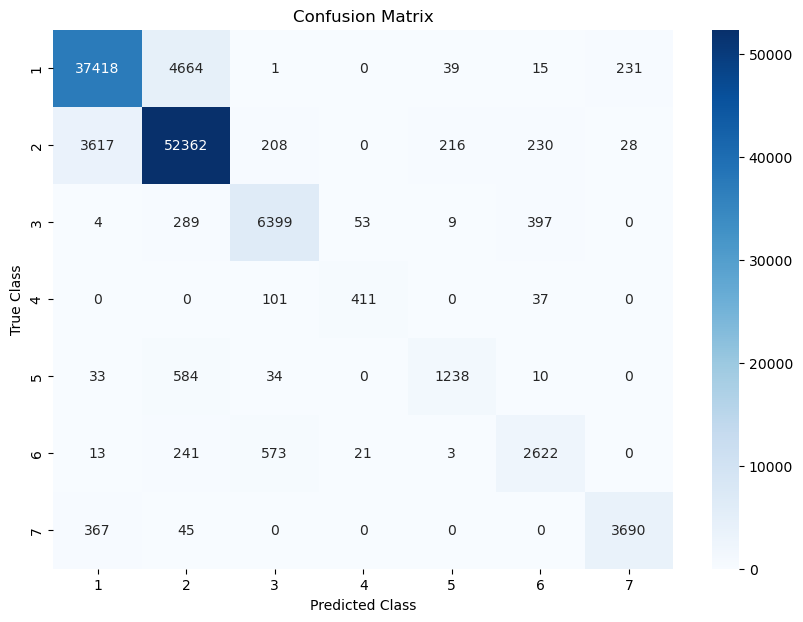

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# Evaluate on Test Set
# ==============================
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=2)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ==============================
# Generate Predictions
# ==============================
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1) + 1  # add 1 to reverse 0-indexing
y_true = y_test.values  # original labels

# ==============================
# Classification Report
# ==============================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# ==============================
# Confusion Matrix Heatmap
# ==============================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

## Final Test Set Performance and Visualisations

The final, best-performing model was evaluated on the held-out test set:

- **Test Accuracy:** 0.8962  
- **Test Loss:** 0.2582  

**Insights from the Classification Report:**

- Classes 1, 2, 3, and 7 perform very well (F1-scores ~0.88–0.92), indicating the model reliably distinguishes these types.  
- Classes 4, 5, and 6 are more difficult. Class 5 in particular shows lower recall (0.65), meaning the model misses a notable fraction of these instances. This difficulty is likely influenced by the dataset’s class distribution. These classes occur far less frequently than the dominant classes, meaning the model is trained on comparatively fewer examples and therefore has less opportunity to learn their distinguishing patterns. 
- Overall weighted F1-score is high (~0.90), suggesting strong general performance despite some minority-class challenges.

**Final Visualisations:**

To better understand model behavior and performance:

1. **Per-Class F1-Score Bar Chart** – clearly shows relative performance across all classes.  
2. **Normalized Confusion Matrix Heatmap** – reveals which classes are confused and to what extent.  
3. **Training vs Validation Curves** – illustrates model learning dynamics, convergence, and potential overfitting trends.

These visualisations provide a concise but complete summary of the model’s performance before final deployment or further analysis.

3632/3632 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


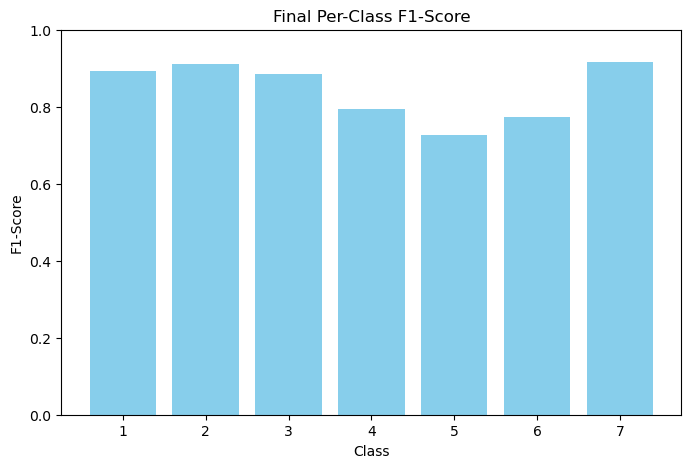

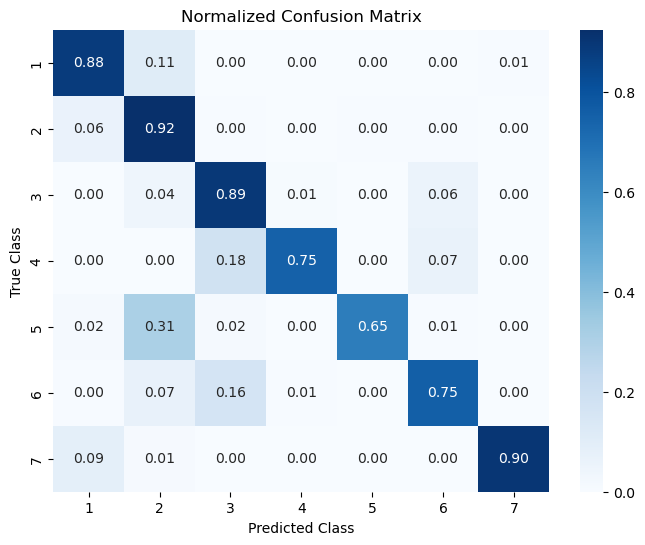

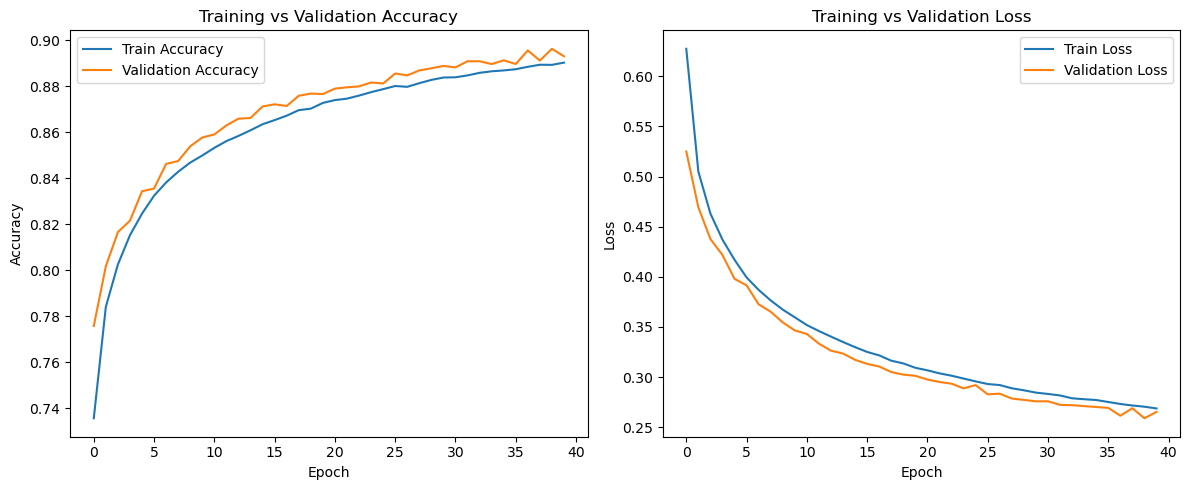

In [19]:
# ==============================
# Final Visualisations
# ==============================

import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix

# Generate predictions for the test set
y_pred = np.argmax(model.predict(X_test), axis=1) + 1  # convert back to original labels
y_true = y_test.values

# ------------------------------
# 1. Per-Class F1-Score Bar Plot
# ------------------------------
f1 = f1_score(y_true, y_pred, labels=np.arange(1, num_classes+1), average=None)

plt.figure(figsize=(8,5))
plt.bar(np.arange(1, num_classes+1), f1, color='skyblue')
plt.xlabel('Class')
plt.ylabel('F1-Score')
plt.title('Final Per-Class F1-Score')
plt.ylim(0, 1.0)
plt.xticks(np.arange(1, num_classes+1))
plt.show()

# ------------------------------
# 2. Normalized Confusion Matrix Heatmap
# ------------------------------
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=np.arange(1, num_classes+1),
            yticklabels=np.arange(1, num_classes+1))
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Confusion Matrix")
plt.show()

# ------------------------------
# 3. Training vs Validation Curves
# ------------------------------
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Final Test Set Performance, Model Comparisons, and Visualisations

The final, best-performing model was evaluated on the held-out test set:

- **Test Accuracy:** 0.8962  
- **Test Loss:** 0.2582  

**Insights from the Classification Report:**

- Classes 1, 2, 3, and 7 perform very well (F1-scores ~0.88–0.92), indicating the model reliably distinguishes these types.  
- Classes 4, 5, and 6 are more difficult. Class 5 in particular shows lower recall (0.65), meaning the model misses a notable fraction of these instances.  
- Overall weighted F1-score is high (~0.90), suggesting strong general performance despite some minority-class challenges.  
- The normalized confusion matrix shows that misclassifications primarily occur among similar classes (e.g., class 4 misclassified as class 3, class 5 as class 2), which reflects overlapping environmental features in the dataset.

**Model Comparisons and Performance:**

- **Initial Base Model:** A simple 128→64→7 architecture gave solid results (~88% train accuracy, ~87–88% validation accuracy). Its straightforward design allowed stable convergence without overfitting.  
- **Final Enhanced Model:** Adding slightly more neurons, a small dropout, and reducing the learning rate led to the best overall results (Test Accuracy 0.8962). The learning rate adjustment and Dropout helped improve generalisation while preserving convergence.  
- **Experimental Models:**  
  - Wider networks with higher dropout (256→128→64) and different batch sizes underperformed (val_accuracy 0.8709, val_loss 0.3201), likely due to over-regularization and difficulty optimizing a larger parameter space.  
  - Very deep/wide GELU-based networks (512→256→128) achieved high accuracy (~0.8658 train) but did not outperform the simpler final model on the test set. This suggests that increased complexity did not yield better generalisation and may have introduced training instability.  

**Interpretation of Model Behavior:**

- Simpler architectures with moderate capacity performed better for this problem because the dataset is large, but the classes have overlapping features, so overcomplicated networks did not improve performance.  
- Classes 1, 2, 3, and 7 are more distinct in feature space, explaining their high accuracy. Classes 4, 5, and 6 are more similar to other cover-types, resulting in confusion that is reflected in the normalized confusion matrix.
- It is also important to consider the class distribution of the dataset. The data is highly imbalanced, with class 2 (48.8%) and class 1 (36.5%) making up the majority of observations, while classes 4 (0.47%), 5 (1.63%), and 6 (2.99%) appear far less frequently. This imbalance likely contributes to the lower recall and F1-scores observed for these minority classes, as the model has significantly fewer examples from which to learn their distinguishing patterns.
  
**Suggestions for Improving Misclassifications:**

- Introduce additional feature engineering (e.g., polynomial features, interaction terms, or environmental domain knowledge).  
- Explore class balancing techniques or weighted losses to improve recall for underrepresented or challenging classes.  
- Experiment with ensemble models (e.g., combining simpler networks or tree-based models with the neural network) to leverage complementary strengths.  
- Minor hyperparameter tuning, such as slightly adjusted dropout, batch size, or learning rate schedules, could provide marginal improvements without overcomplicating the network.

**Final Visualisations:**

1. **Per-Class F1-Score Bar Chart** – clearly shows relative performance across all classes.  
2. **Normalized Confusion Matrix Heatmap** – reveals which classes are confused and to what extent.  
3. **Training vs Validation Curves** – illustrates model learning dynamics, convergence, and potential overfitting trends.  

**Conclusion:**

The final model demonstrates strong performance on a challenging multi-class classification problem. The learning curves and confusion matrix indicate the model generalises well, with expected misclassifications among similar classes. Some of the remaining errors are likely influenced by the dataset’s class imbalance, where certain cover types appear far less frequently and therefore provide fewer examples for the model to learn from. Simpler architectures with careful tuning outperformed overly complex networks, showing that moderate capacity and well-chosen hyperparameters are crucial for achieving the best results. Overall, this provides a solid example of iterative model development, evaluation, and interpretation.